##### Adriana Rangel Martínez

In [9]:
import pandas as pd
from sklearn.cluster import KMeans
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

# Lectura de datos

In [11]:
#En esta sección se hace la lectura y unión de los archivos que contienen los datos y
#se transforman a dataframe.

In [12]:
os.chdir('C:/Users/Adriana Rangel')

In [13]:
#Subir archivos
sales=pd.read_csv('FACT_SALES.csv')
calendar=pd.read_excel('DIM_CALENDAR.xlsx')
product=pd.read_excel('DIM_PRODUCT.xlsx')
segment=pd.read_excel('DIM_SEGMENT.xlsx')
category=pd.read_csv("DIM_CATEGORY.csv")


In [14]:
category

,ID_CATEGORY,CATEGORY
0,1,FABRIC TREATMENT and SANIT\r\n
1,2,AIR CARE
2,3,LAVAVAJILLAS
3,4,MEGA SUPERFICIES
4,5,LAVATORY CARE & BRC


In [ ]:
#renombrar columnas
sales.rename(columns = {"WEEK":"SEMANA DEL AÑO","ITEM_CODE":"CODIGO","TOTAL_UNIT_SALES":"TOTAL DE UNIDADES VENDIDAS","TOTAL_VALUE_SALES":"VALOR TOTAL DE VENTAS","TOTAL_UNIT_AVG_WEEKLY_SALES":"TOTAL DE UNIDADES PROMEDIO SEMANAL"}, inplace=True)
#sales.head()

In [1107]:
#renombrar columnas
calendar.rename(columns={"WEEK":"SEMANA DEL AÑO","YEAR":"AÑO","MONTH":"MES","WEEK_NUMBER":"NUMERO DE SEMANAS","DATE":"FECHA"}, inplace=True)
#calendar.head()

In [29]:
#renombrar columnas
product.rename(columns={"MANUFACTURER":"FABRICANTE","BRAND":"MARCA","ITEM":"CODIGO","ITEM_DESCRIPTION":"DESCRIPCIÓN DEL PRODUCTO","CATEGORY":"CATEGORIA","FORMAT":"FORMATO"},inplace=True)
product.head()

,FABRICANTE,MARCA,CODIGO,DESCRIPCIÓN DEL PRODUCTO,CATEGORIA,FORMATO,ATTR1,ATTR2,ATTR3
0,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO
1,INDS. ALEN,CLORALEX,0000075000608,CLORALEX EL RENDIDOR BOT.PLAST. 500ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO
2,INDS. ALEN,CLORALEX,0000075000615,CLORALEX EL RENDIDOR BOT.PLAST. 950ML NAL. 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO
3,INDS. ALEN,CLORALEX,0000075000622,CLORALEX EL RENDIDOR BOT.PLAST. 2000ML NAL 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO
4,INDS. ALEN,CLORALEX,0000075000639,CLORALEX EL RENDIDOR BOT.PLAST. 3750ML NAL 000...,1,LIQUIDO,CLORO,CLORO,NO DEFINIDO


In [37]:
#renombrar columnas
segment.rename(columns={"CATEGORY":"CATEGORIA","FORMAT":"FORMATO","SEGMENT":"SEGMENTO"},inplace=True)
#segment.head()

# Union de datos

In [1116]:
#realizar la union entre Product y Sales (tienen en común el código del producto)
union=pd.merge(product,sales)
#union

In [1118]:
#realizar la union entre Product, sales y segment
union2=pd.merge(union,segment)
#union2

In [1120]:
#realizar la union entre product, sales, segment y calendar
union3=pd.merge(calendar,union2)
#union3.info()

In [1122]:
#eliminar columnas con la misa información 
union3.drop(columns=["SEMANA DEL AÑO","AÑO","MES"], axis=1, inplace=True)
#union3

In [1124]:
#verificar el número de productos diferentes
#union3["CODIGO"].value_counts()

In [1126]:
#verificar el núero de categorias
union3["CATEGORIA"].value_counts()
#solo hay una categoria por lo que podemos eliminar esa columna

CATEGORIA
1    122002
Name: count, dtype: int64

In [1128]:
#verificar el núero de segmentos
#union3["SEGMENTO"].value_counts()

In [1132]:
#verificar el número de regiones
union3["REGION"].value_counts()

REGION
TOTAL AUTOS SCANNING MEXICO    20990
TOTAL AUTOS AREA 2             18505
TOTAL AUTOS AREA 4             17182
TOTAL AUTOS AREA 6             16913
TOTAL AUTOS AREA 3             16496
TOTAL AUTOS AREA 5             16135
TOTAL AUTOS AREA 1             15781
Name: count, dtype: int64

In [1134]:
#verificar el número de atributos "ATTR3"
#union3["ATTR3"].value_counts()

In [1136]:
#verificar el número de fabricantes
#union3["FABRICANTE"].value_counts()

In [1138]:
#Como no todas la columnas son relevantes podemos desasernos de algunas, por ejemplo de categoría, ya que 
#solo hay una categoría. También podemos quitar ATTR1 y ATTR2 ya que esas clasificaciones a mi parecer
#No son muy relevantes

In [1140]:
union3.drop(columns=["ATTR1","ATTR2","CATEGORIA","NUMERO DE SEMANAS"],axis=1,inplace=True)
#union3

# Modelo de regresión 

Creo que no es práctico aplicar un modelo de regresión lineal porque los datos están divididos por muchas
categorías (segmento, región, formato, características, fabricante...) y si queremos explicar el valor
total de las ventas, debemos de tomar en cuenta casi todas la demás variables para hacer un buen modelo 
predictivo, el problema es que no todas las variables tienen formato numérico continuo y eso hace más engorrosa la
tarea de construir el modelo.

# Modelo serie de tiempo

Aplicar un modelo de serie de tiempo es más sencillo ya que la variable independiente es el tiempo y la dependiente
en este caso puede ser el valor total de las ventas. La estrategia que se siguió para este analisis fue
dividir los datos por región, para poder tener una visión más profunda y modelos mejor adaptados a cada región.

## TOTAL DE UNIDADES PROMEDIO SEMANAL

In [1148]:
#Filtrado de datos por región
region_1=union3.loc[union3['REGION']=='TOTAL AUTOS AREA 1']
region_2=union3.loc[union3['REGION']=='TOTAL AUTOS AREA 2']
region_3=union3.loc[union3['REGION']=='TOTAL AUTOS AREA 3']
region_4=union3.loc[union3['REGION']=='TOTAL AUTOS AREA 4']
region_5=union3.loc[union3['REGION']=='TOTAL AUTOS AREA 5']
region_6=union3.loc[union3['REGION']=='TOTAL AUTOS AREA 6']
region_mexico=union3.loc[union3['REGION']=='TOTAL AUTOS SCANNING MEXICO']

#region_1

# Caso del área 1

In [4]:
#Se agrupan los datos por fecha de tal forma que se muestre la suma del total de unidades promedio semanal 
#para cada fecha
ventas_sem1=region_1.groupby('FECHA',as_index=False)['TOTAL DE UNIDADES PROMEDIO SEMANAL'].sum()


NameError: name 'region_1' is not defined

In [946]:
#Definición de grupos de prueba y de entrenamiento
#Se eligen las primeras fechas para grupos de entrenamiento y las últimas para grupos de prueba
len_train=int(len(ventas_sem1)*0.9)
len_test=int(len(ventas_sem1)*0.1)
train=ventas_sem1[0:len_train]
test=ventas_sem1[len_train:]

In [948]:
#train

In [950]:
#test

In [952]:
#Prueba de estacionalidad de Dickey-Fuller para saber si la serie es estacionaria o no.
#HO: La serie es no estacionaria, es decir que la media va cambiando a lo largo del tiempo
#HA: la serie es estacionaria
from statsmodels.tsa.stattools import adfuller
result=adfuller(train['TOTAL DE UNIDADES PROMEDIO SEMANAL'])
print('Elvalor p de la prueba de Dicey-Fuller es: ', result[1])

Elvalor p de la prueba de Dicey-Fuller es:  0.8052919551225427


In [954]:
#Como el valor p es mayor a 5% no se puede rechazar la hipotesis nula

In [956]:
#Se aplican primeras diferencias para convertir la serie en una serie estacionaria
train['DIF_PROMEDIO']=train['TOTAL DE UNIDADES PROMEDIO SEMANAL'].diff()
train=train.dropna()
#train

In [958]:
#Aplicación de la prueba Dickie-Fuller sobre las diferencias
result2=adfuller(train['DIF_PROMEDIO'])
print('El valor p de la prueba Dickey-Fuller es: ', result2[1])

El valor p de la prueba Dickey-Fuller es:  0.00015431009995103663


In [960]:
#Vemos que el valor de p ya es menor al 5%, con lo que, podemos descartar la hipotesis nula
#y concluir que las serie es estacionaria 

<Axes: >

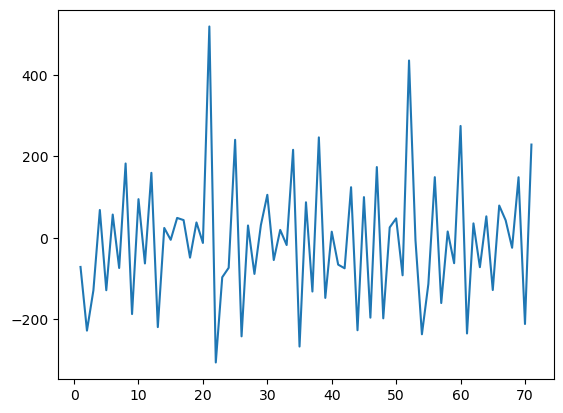

In [962]:
train['DIF_PROMEDIO'].plot()

La gráfica nos ayuda a visualizar como la media de los datos sigue un patrón estacionario.

In [1153]:
#Importación del módulo para estimar el modelo arima
from statsmodels.tsa.arima.model import ARIMA
#Ajustar los datos a un modelo AR(1) e imprimir su AIC (índice de información de akaiki):
#se aplica sobre los datos transformados
mod_ar8=ARIMA(train['DIF_PROMEDIO'],order=(8,0,2))
res_ar8=mod_ar8.fit()
print('El AIC para AR(8) es: ',res_ar8.aic)

El AIC para AR(8) es:  898.4244295849443


#Esta prueba se hizo para diferentes hiperparámetros, pero el indice de información de akaiki más bajo fue para 
AR(8,1,2), en donde, el uno de enmedio significa la aplicación de una diferencia.

Conclusión: la serie de tiempo original del total de unidades promedio semanal se modela bien con ARIMA (8,1,2), 

# Validación del modelo

In [969]:
#importación del modelo arima de statsmodels
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_predict
#pronostico de temperatura usando un modelo arima
mod=ARIMA(train['TOTAL DE UNIDADES PROMEDIO SEMANAL'],order=(8,1,1))
res=mod.fit()

In [970]:
len_test

8

In [971]:
#Pronostico puntual 
predicciones=res.forecast(len_test)
#predicciones

In [973]:
predicciones=pd.DataFrame(predicciones)
predicciones=predicciones.reset_index()
#predicciones

In [976]:
predicciones.drop(columns=['index'],inplace=True)
#predicciones

In [978]:
predicciones.rename(columns={'predicted_mean':'predicted'},inplace=True)
#predicciones

In [980]:
#Se guardan los datos de prueba en un dataframe llamado lista
lista=test['FECHA']
lista=pd.DataFrame(lista)
train.index=train['FECHA']
train.drop(columns=['FECHA'],inplace=True)
test.index=test['FECHA']
test.drop(columns=['FECHA'],inplace=True)
#test

In [981]:
#train

In [983]:
lista=lista.reset_index(drop=True)
#lista

In [985]:
#Ahora juntamos las fechas con sus predicciones
frames=[lista,predicciones]
result=pd.concat(frames, axis=1, join='inner')
result.columns=['FECHA','Predicciones']
#result

In [988]:
result.index=result['FECHA']
result.drop(columns=['FECHA'],inplace=True)
#result

In [989]:
import numpy as np
acumulador1=0
acumulador2=0
for contador in range(0,8):
    acumulador1=acumulador1+(test.iloc[contador,0]-predicciones.iloc[contador,0])**2
    acumulador2=acumulador2+np.abs((test.iloc[contador,0]-predicciones.iloc[contador,0])/test.iloc[contador,0])
mse=acumulador1/8
rmse=np.round(np.sqrt(mse),2)
mape=np.round((acumulador2/8)*100,2)
print('RMSE = ',rmse,'MAPE = ',mape,'%')

RMSE =  130.23 MAPE =  6.42 %


La raíz del error cuadrático medio (RMSE) es de 130.23, lo cual significa que, el error promedio del total 
de unidades promedio semanal predicho con este modelo es de 130.23 unidades. 
Además el error porcentual absoluto promedio (MAPE) es del 6.42% lo que significa que, el modelo se equivoca en 
proedio el 6.42% de las veces. 


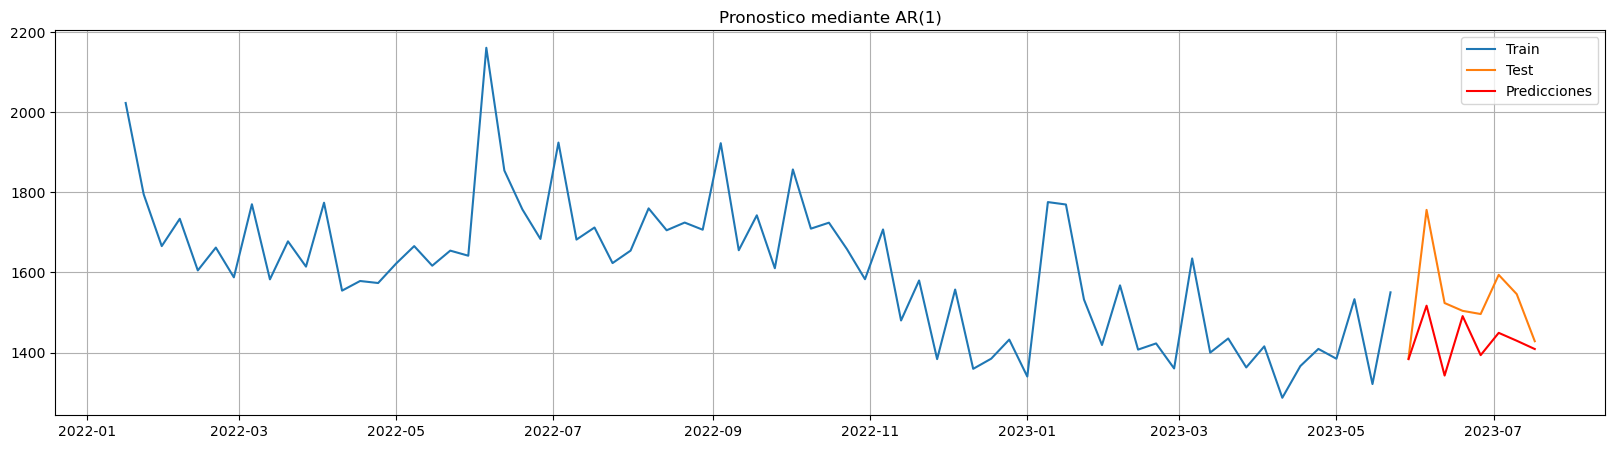

In [991]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20,5))
plt.grid()
plt.plot(train['TOTAL DE UNIDADES PROMEDIO SEMANAL'], label='Train')
plt.plot(test['TOTAL DE UNIDADES PROMEDIO SEMANAL'],label='Test')
plt.plot(result,label='Predicciones',color='red')
plt.legend(loc='best')
plt.title('Pronostico mediante AR(8)')
plt.show()

La gráfica muestra los datos de prueba, los de entrenamiento y las predicciones.
Se puede ver que las redicciones tienen valores mucho mpas altos que los datos reales.

## VALOR TOTAL DE VENTAS
## CASO AREA 1	

Aquí se analizó la variable del valor total de ventas para la región 1

In [1160]:
valor_tot=region_1.groupby('FECHA',as_index=False)['VALOR TOTAL DE VENTAS'].sum()
#valor_tot

In [1162]:
#Definición de grupos de prueba y de entrenamiento
#Se eligen las primeras fechas para grupos de entrenamiento y las últimas para grupos de prueba
len_train=int(len(valor_tot)*0.9)
len_test=int(len(valor_tot)*0.1)
train_v=valor_tot[0:len_train]
test_v=valor_tot[len_train:]

In [1164]:
#Prueba de estacionalidad de Dickey-Fuller
#HO: La serie es no estacionaria, es decir que la media va cambiando a lo largo del tiempo
#HA: la serie es estacionaria
from statsmodels.tsa.stattools import adfuller
result_v=adfuller(train_v['VALOR TOTAL DE VENTAS'])
print('Elvalor p de la prueba de Dicey-Fuller es: ', result_v[1])

Elvalor p de la prueba de Dicey-Fuller es:  0.163029296225149


Como el valor p es mayor al 5% no se puede concluir que la serie es estacionaria y necesita ser diferenciada

In [1167]:
#Se aplican primeras diferencias para convertir la serie en una serie estacionaria
train_v['DIF_VALOR']=train_v['VALOR TOTAL DE VENTAS'].diff()
train_v=train_v.dropna()
#train_v

In [1169]:
#Aplicación de la prueba Dickie-Fuller sobre las diferencias
result3=adfuller(train_v['DIF_VALOR'])
print('El valor p de la prueba Dickey-Fuller es: ', result3[1])

El valor p de la prueba Dickey-Fuller es:  0.09446886367599638


Como el valor p es mayor al 5% no se puede concluir que la serie es estacionaria y necesita ser diferenciada otra vez

In [1172]:
#Se aplican primeras diferencias para convertir la serie en una serie estacionaria
train_v['DIF_VALOR_2']=train_v['DIF_VALOR'].diff()
train_v=train_v.dropna()
#train_v

In [1174]:
#Aplicación de la prueba Dickie-Fuller sobre las diferencias
result3=adfuller(train_v['DIF_VALOR_2'])
print('El valor p de la prueba Dickey-Fuller es: ', result3[1])

El valor p de la prueba Dickey-Fuller es:  2.204187773238329e-08


Ahora sí, el valor p es menor al 5%, así que se puede concluir que la serie es estacionaria.

<Axes: >

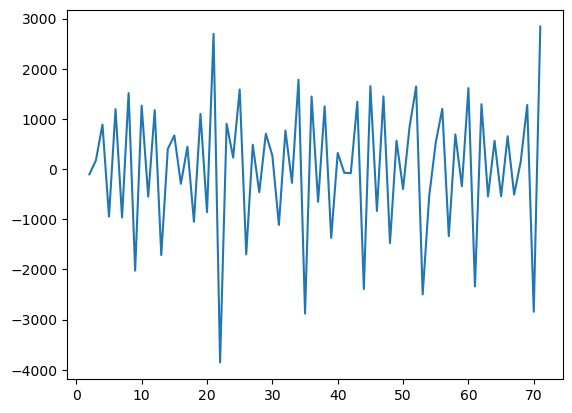

In [1010]:
train_v['DIF_VALOR_2'].plot()

La gráfica nos ayuda a visualizar como la media de los datos sigue un patrón estacionario.

In [1012]:
#Importación del módulo para estimar el modelo arima
from statsmodels.tsa.arima.model import ARIMA
#Ajustar los datos a un modelo AR(1) e imprimir su AIC (índice de información de akaiki):
#se aplica sobre los datos transformados
mod_ar8=ARIMA(train_v['DIF_VALOR_2'],order=(8,0,0))
res_ar8=mod_ar8.fit()
print('El AIC para AR(1) es: ',res_ar8.aic)

El AIC para AR(1) es:  1107.1778198342142


Para p=8, d=0 y q=0 dio el AIC más bajo, así que estos son los valores óptimos para la serie de tiempo. 

# Validación del modelo

In [1184]:
#importación del modelo arima de statsmodels
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_predict
#pronostico de temperatura usando un modelo arima
mod=ARIMA(train_v['VALOR TOTAL DE VENTAS'],order=(8,2,0))
res=mod.fit()

In [1185]:
#Pronostico puntual 
predicciones_v=res.forecast(len_test)
predicciones_v

70     9710.396487
71    10574.396007
72     9713.972729
73    10772.890273
74    10332.649635
75    10914.440654
76    11133.125689
77    10962.359505
Name: predicted_mean, dtype: float64

In [1188]:
predicciones_v=pd.DataFrame(predicciones_v)
predicciones_v=predicciones_v.reset_index()
#predicciones_v

In [1190]:
predicciones_v.drop(columns=['index'],inplace=True)
#predicciones_v

In [1192]:
predicciones_v.rename(columns={'predicted_mean':'predicted'},inplace=True)
#predicciones_v

In [1194]:
#Se guardan los datos de prueba en un dataframe llamado lista
lista2=test_v['FECHA']
lista2=pd.DataFrame(lista)
train_v.index=train_v['FECHA']
train_v.drop(columns=['FECHA'],inplace=True)
test_v.index=test_v['FECHA']
test_v.drop(columns=['FECHA'],inplace=True)


In [1196]:
#lista2

In [1198]:
lista2=lista2.reset_index(drop=True)

In [1200]:
#Ahora juntamos las fechas con sus predicciones
frames=[lista2,predicciones_v]
result_v=pd.concat(frames, axis=1, join='inner')
result_v.columns=['FECHA','Predicciones']
#result

In [1202]:
result_v.index=result_v['FECHA']
result_v.drop(columns=['FECHA'],inplace=True)
#result

In [1204]:
import numpy as np
acumulador1=0
acumulador2=0
for contador in range(0,8):
    acumulador1=acumulador1+(test_v.iloc[contador,0]-predicciones_v.iloc[contador,0])**2
    acumulador2=acumulador2+np.abs((test_v.iloc[contador,0]-predicciones_v.iloc[contador,0])/test_v.iloc[contador,0])
mse=acumulador1/8
rmse=np.round(np.sqrt(mse),2)
mape=np.round((acumulador2/8)*100,2)
print('RMSE = ',rmse,'MAPE = ',mape,'%')

RMSE =  888.94 MAPE =  8.09 %


La raíz del error cuadrático medio (RMSE) es de 888.94, lo cual significa que, el error promedio del total 
de unidades promedio semanal predicho con este modelo es de 888.94 unidades. 
Además, el error porcentual absoluto promedio (MAPE) es del 8.09% lo que significa que, el modelo se equivoca en 
proedio el 8.09% de las veces. 

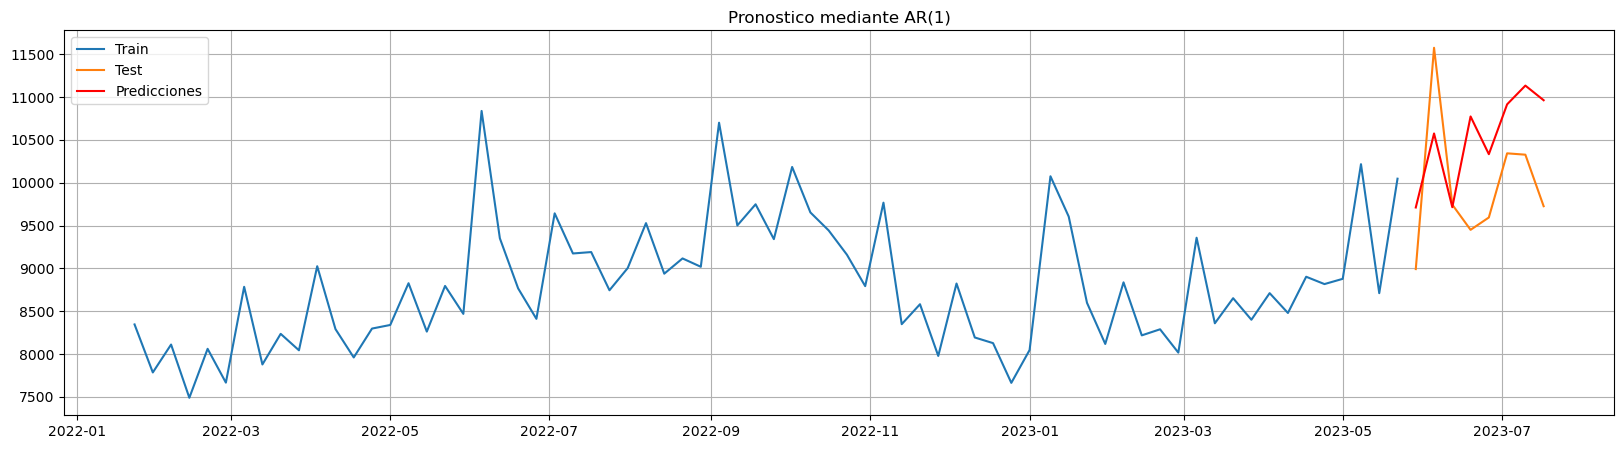

In [1037]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20,5))
plt.grid()
plt.plot(train_v['VALOR TOTAL DE VENTAS'], label='Train')
plt.plot(test_v['VALOR TOTAL DE VENTAS'],label='Test')
plt.plot(result_v,label='Predicciones',color='red')
plt.legend(loc='best')
plt.title('Pronostico mediante AR(8)')
plt.show()

La gráfica muestra los datos de prueba, los de entrenamiento y las predicciones.
Se puede ver que las predicciones y los datos de prueba siguen una tendencia parecida 
de aumentar gradualmente con el tiempo.

# Prueba del modelo AR(p) sobre el valor total de las ventas

Se intentó implementar otro tiepo de modelo de serie de tiempo del tipo autorregresiva.

In [1043]:
import matplotlib.pyplot as plt
#Generación de la funcion de autocorrelación de manera general
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf

[ 1.          0.38285423  0.39942931  0.18135939  0.43153519  0.2388506
  0.10345945  0.06748388  0.08491706  0.27027317 -0.07422467  0.00885834
 -0.14017336  0.19285742 -0.09890236 -0.03725935 -0.19407534  0.02388118
 -0.08246707]


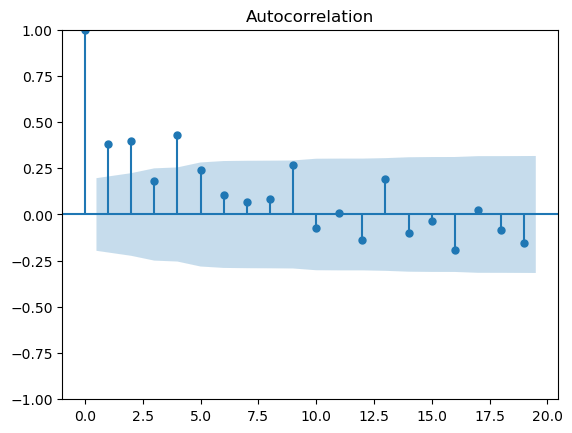

In [1044]:
acf_array=acf(train_v['VALOR TOTAL DE VENTAS'])
print(acf_array)
#Gráfico con un nivel 90%
plot_acf(train_v['VALOR TOTAL DE VENTAS'],alpha=0.1)
plt.show()

Sin embargo, no hay una autocorrelación bien definida entre valores consecutivos, además no es una serie estacionaria así que no es correcto aplicar este tipo de modelo autorregresivo.

# Utiliza el modelo optimizado para predecir las ventas futuras para los próximos meses.

In [1048]:
#test

In [1050]:
#Se definen las fechas de las siguientes 8 semanas y se guardan en una lista llamada lista 2
k=21
fechas=[]
for week in range(1,17):
    fecha=((pd.to_datetime('2023-05-22')+pd.DateOffset(weeks=week)).date())
    fechas.append(fecha)
fechas=pd.DataFrame(fechas,columns=['Date'])
fechas['Date']=pd.to_datetime(fechas['Date'])
#fechas

In [1052]:
#Y aquí se calculan los pronostico de las siguientes 8 semanas. 
predicciones_futuras=res.forecast(len(test)+8)
#predicciones_futuras.tail(8)

In [1053]:
#Se convienrten a dataframe la lista de predicciones_futuras
predicciones_futuras=pd.DataFrame(predicciones_futuras)
predicciones_futuras=predicciones_futuras.reset_index()
#predicciones_futuras

In [1055]:
#Se elimina la columna de index
predicciones_futuras.drop(columns=['index'],inplace=True)
#predicciones_futuras

In [1056]:
#Ahora juntamos las fechas con sus predicciones
frames=[fechas,predicciones_futuras]
result=pd.concat(frames, axis=1, join='inner')
result.columns=['FECHA','PREDICCIONES']
#result

De aquí podemos dividir las predicciones que se ajustan a los datos de prueba y las predicciones de los futuros 2 meses.

In [1059]:
result_test=result.iloc[0:8]
result_prediccion=result.iloc[8:]

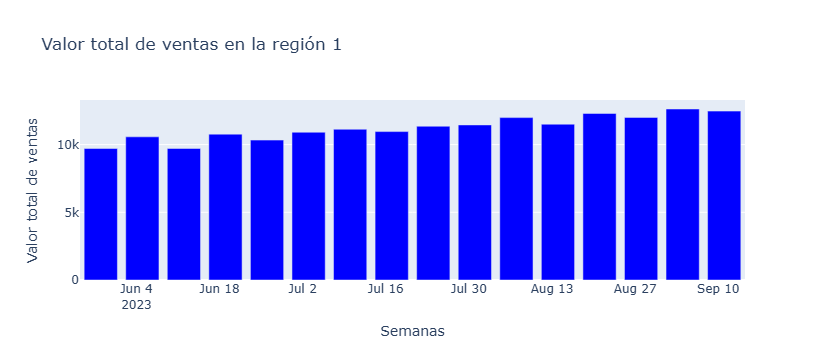

In [1279]:
#Gráfico del valor total de ventas en la región 1 por fechas
from plotly.subplots import make_subplots
import plotly.graph_objects as go
fig1=go.Figure()
fig1.add_trace(go.Bar(x=result['FECHA'],y=result['PREDICCIONES'],name='Valor total de ventas en la región 1',marker=dict(color='blue')))
fig1.update_layout(title='Valor total de ventas en la región 1',yaxis_title='Valor total de ventas',xaxis_title='Semanas')
fig1.show()

Se observa una tendencia del aumento de las ventas en la región 1, desde junio hasta septiembre, sin embargo, las últimas semanas presentan valores muy a la par. Aquí los que se podría cuidar es que el valor total de las ventas se mantenga constante.

In [1221]:
test_v = test_v.reset_index()
#test_v 

In [1223]:
test_v.drop(columns=['index'],inplace=True)
#test_v

KeyError: "['index'] not found in axis"

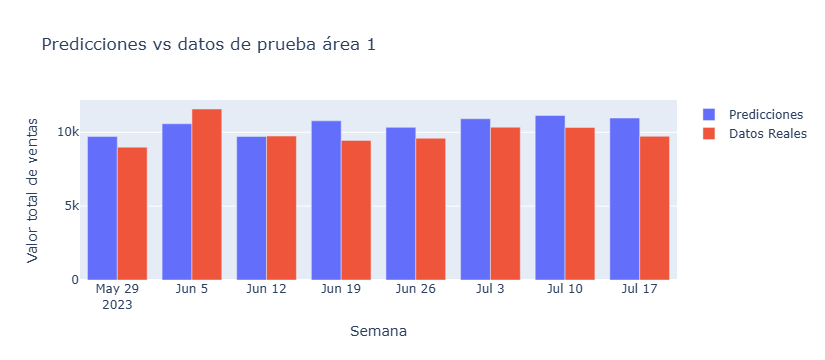

In [1283]:
#Gráfica de población por sexo
from plotly.subplots import make_subplots
import plotly.graph_objects as go
fig2=go.Figure()
#fig=make_subplots(rows=2,cols=1,subplot_titles=('Población total mundial','Población masculina mundial'))
fig2.add_trace(go.Bar(x=result_test['FECHA'],y=result_test['PREDICCIONES'],name='Predicciones'))
fig2.add_trace(go.Bar(x=test_v['FECHA'], y=test_v['VALOR TOTAL DE VENTAS'],name='Datos Reales'))
fig2.update_layout(title='Predicciones vs datos de prueba área 1',xaxis_title='Semana', yaxis_title='Valor total de ventas',barmode='group',height=700)
fig2.show()

En esta gráfica se muestran las predicciones en azul y los datos reales en rojo, precisamente para los datos
de prueba, se observa que engeneral las predicciones de cada semana explican bien la tendencia de los datos reales. Lo cual habla de un buen modelo.

## VALOR TOTAL DE VENTAS
## CASO AREA 2	

Aquí se analizó la variable del valor total de ventas para la región 2

In [1228]:
valor_tot_2=region_2.groupby('FECHA',as_index=False)['VALOR TOTAL DE VENTAS'].sum()
#valor_tot_2

In [1230]:
#Definición de grupos de prueba y de entrenamiento
#Se eligen las primeras fechas para grupos de entrenamiento y las últimas para grupos de prueba
len_train_2=int(len(valor_tot_2)*0.9)
len_test_2=int(len(valor_tot_2)*0.1)
train_v_2=valor_tot_2[0:len_train_2]
test_v_2=valor_tot_2[len_train_2:]

In [1232]:
#Prueba de estacionalidad de Dickey-Fuller
#HO: La serie es no estacionaria, es decir que la media va cambiando a lo largo del tiempo
#HA: la serie es estacionaria
from statsmodels.tsa.stattools import adfuller
result_v_21=adfuller(train_v_2['VALOR TOTAL DE VENTAS'])
print('Elvalor p de la prueba de Dicey-Fuller es: ', result_v_21[1])

Elvalor p de la prueba de Dicey-Fuller es:  0.11008426527933657


Como el valor p es mayor al 5% no se puede concluir que la serie es estacionaria y necesita ser diferenciada

In [1235]:
#Se aplican primeras diferencias para convertir la serie en una serie estacionaria
train_v_2['DIF_VALOR']=train_v_2['VALOR TOTAL DE VENTAS'].diff()
train_v_2=train_v_2.dropna()
#train_v_2

In [1237]:
#Aplicación de la prueba Dickie-Fuller sobre las diferencias
result_v_22=adfuller(train_v_2['DIF_VALOR'])
print('El valor p de la prueba Dickey-Fuller es: ', result_v_22[1])

El valor p de la prueba Dickey-Fuller es:  0.20086802085300048


Como el valor p es mayor al 5% no se puede concluir que la serie es estacionaria y necesita ser diferenciada otra vez

In [1240]:
#Se aplican primeras diferencias para convertir la serie en una serie estacionaria
train_v_2['DIF_VALOR_2']=train_v_2['DIF_VALOR'].diff()
train_v_2=train_v_2.dropna()
#train_v_2

In [1242]:
#Aplicación de la prueba Dickie-Fuller sobre las diferencias
result_v_23=adfuller(train_v_2['DIF_VALOR_2'])
print('El valor p de la prueba Dickey-Fuller es: ', result_v_23[1])

El valor p de la prueba Dickey-Fuller es:  9.685330767083582e-12


Ahora sí, el valor p es menor al 5%, así que se puede concluir que la serie es estacionaria.

<Axes: xlabel='FECHA'>

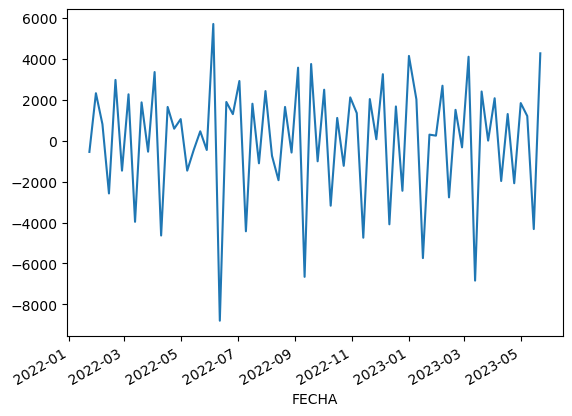

In [1070]:
train_v_2['DIF_VALOR_2'].plot()

La gráfica nos ayuda a visualizar como la media de los datos sigue un patrón estacionario.

In [1246]:
#Importación del módulo para estimar el modelo arima
from statsmodels.tsa.arima.model import ARIMA
#Ajustar los datos a un modelo AR(1) e imprimir su AIC (índice de información de akaiki):
#se aplica sobre los datos transformados
mod_ar=ARIMA(train_v_2['DIF_VALOR_2'],order=(8,0,0))
res_ar=mod_ar.fit()
print('El AIC para AR(1) es: ',res_ar.aic)

El AIC para AR(1) es:  1214.8513865380444


Para p=8, d=0 y q=0 dio el AIC más bajo, así que estos son los valores óptimos.

# Validación del modelo

In [1250]:
#importación del modelo arima de statsmodels
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_predict
#pronostico de temperatura usando un modelo arima
mod=ARIMA(train_v_2['VALOR TOTAL DE VENTAS'],order=(8,2,0))
res2=mod.fit()

In [1252]:
#Pronostico puntual 
predicciones_v_2=res2.forecast(len_test_2)
#predicciones_v_2

In [1254]:
predicciones_v_2=pd.DataFrame(predicciones_v_2)
predicciones_v_2=predicciones_v_2.reset_index()
#predicciones_v_2

In [1255]:
predicciones_v_2.drop(columns=['index'],inplace=True)
#predicciones_v_2

In [1256]:
predicciones_v_2.rename(columns={'predicted_mean':'predicted'},inplace=True)
#predicciones_v_2

In [1260]:
#Ahora juntamos las fechas con sus predicciones
frames_2=[lista2,predicciones_v_2]
result_v_2=pd.concat(frames_2, axis=1, join='inner')
result_v_2.columns=['FECHA','Predicciones']
#result_v_2

In [1261]:
result_v_2.index=result_v_2['FECHA']
result_v_2.drop(columns=['FECHA'],inplace=True)
#result_v_2

In [1262]:
#Se reescribe el index como la columna fecha
train_v_2.index=train_v_2['FECHA']
train_v_2.drop(columns=['FECHA'],inplace=True)
test_v_2.index=test_v_2['FECHA']
test_v_2.drop(columns=['FECHA'],inplace=True)
#test_v_2

In [1263]:
import numpy as np
acumulador1=0
acumulador2=0
for contador in range(0,8):
    acumulador1=acumulador1+(test_v_2.iloc[contador,0]-predicciones_v_2.iloc[contador,0])**2
    acumulador2=acumulador2+np.abs((test_v_2.iloc[contador,0]-predicciones_v_2.iloc[contador,0])/test_v_2.iloc[contador,0])
mse=acumulador1/8
rmse=np.round(np.sqrt(mse),2)
mape=np.round((acumulador2/8)*100,2)
print('RMSE = ',rmse,'MAPE = ',mape,'%')

RMSE =  1831.55 MAPE =  9.12 %


La raíz del error cuadrático medio (RMSE) es de 1831.55, lo cual significa que, el error promedio del total 
de unidades promedio semanal predicho con este modelo es de 1831.55 unidades. 
Además, el error porcentual absoluto promedio (MAPE) es del 9.12% lo que significa que, el modelo se equivoca en 
proedio el 9.12% de las veces. 

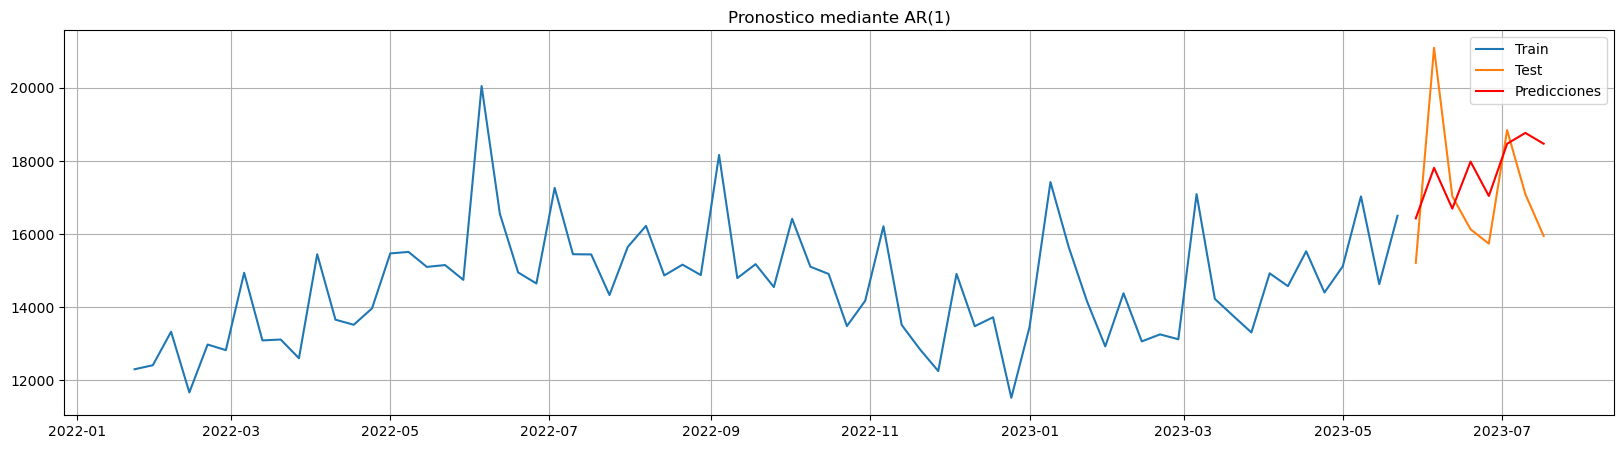

In [1264]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20,5))
plt.grid()
plt.plot(train_v_2['VALOR TOTAL DE VENTAS'], label='Train')
plt.plot(test_v_2['VALOR TOTAL DE VENTAS'],label='Test')
plt.plot(result_v_2,label='Predicciones',color='red')
plt.legend(loc='best')
plt.title('Pronostico mediante AR(8)')
plt.show()

La gráfica muestra los datos de prueba, los de entrenamiento y las predicciones.
Se puede ver que las predicciones y los datos de prueba siguen una tendencia parecida 
de aumentar con el tiempo, sin embargo los datos de prueba tienen subidas y bajadas más pronunciadas. Este modelo 
aunque no es tan reciso en los valore, creo que puede ser tomado como referencia para las tendencias de venta, es decir 
si las ventas tenderan a subir o a bajar en el tiempo.

# Utiliza el modelo optimizado para predecir las ventas futuras para los próximos meses.

In [ ]:
#Y aquí se calculan los pronostico de las siguientes 8 semanas. 
predicciones_futuras2=res2.forecast(len(test_v_2)+8)
#predicciones_futuras2

In [ ]:
#Se convienrten a dataframe la lista de predicciones_futuras
predicciones_futuras2=pd.DataFrame(predicciones_futuras2)
predicciones_futuras2=predicciones_futuras2.reset_index()
#predicciones_futuras2

In [ ]:
#Se elimina la columna de index
predicciones_futuras2.drop(columns=['index'],inplace=True)
predicciones_futuras2

In [1085]:
#Ahora juntamos las fechas con sus predicciones
frames=[fechas,predicciones_futuras2]
result_v_2=pd.concat(frames, axis=1, join='inner')
result_v_2.columns=['FECHA','PREDICCIONES']
#result

De aquí podemos dividir las predicciones que se ajustan a los datos de prueba y las predicciones de los futuros 2 meses.

In [1093]:
result_test_2=result_v_2.iloc[0:8]
result_prediccion_2=result_v_2.iloc[8:]

Por último, se realizó una gráfica para compara las predicciones del valor de las ventas totales para el área 1 y el área 2
para los siguientes dos meses desde el último dato. 

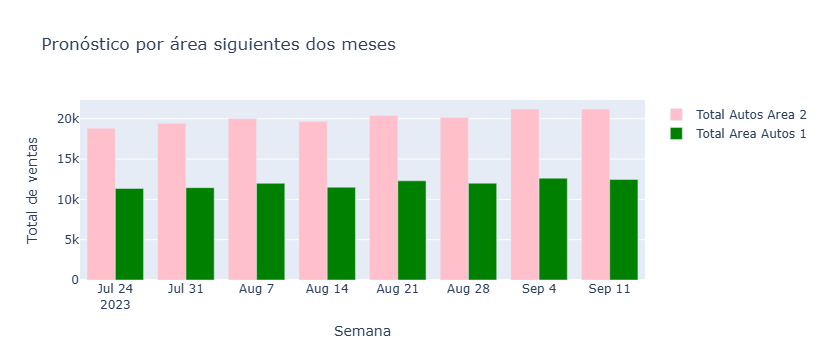

In [1287]:
#Gráfico de población por continentes
from plotly.subplots import make_subplots
import plotly.graph_objects as go
fig3=go.Figure()
fig3.add_trace(go.Bar(x=result_prediccion_2['FECHA'],y=result_prediccion_2['PREDICCIONES'],name='Total Autos Area 2',marker=dict(color='pink')))
fig3.add_trace(go.Bar(x=result_prediccion['FECHA'],y=result_prediccion['PREDICCIONES'],name='Total Area Autos 1',marker=dict(color='green')))
fig3.update_layout(title='Pronóstico por área siguientes dos meses',xaxis_title='Semana',yaxis_title='Total de ventas')
fig3.show()

Se observa que en general hay mayores ganancias en el área 2, que en el área 1. Así que hay que investigar a que se debe esto
Además la tendencia muestra que en las últimas 8 semanas se irá incrementando gradualmente el valor de las ventas
y se tendrán máximos de ganancias en septiembre. 

In [1289]:
import dash
from dash import dcc
from dash import html
#Consolidación de gráficos
app=dash.Dash(__name__)
app.layout=html.Div([
    html.H1('Cuadro de control de Mando (Dashboard)'),
    html.Div([dcc.Graph(figure=fig2), dcc.Graph(figure=fig3),],style={'display':'flex'}),
])
if __name__=='__main__':
    app.run(debug=True)